# Fraud Detection

Importing the Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
!pip install MiniSom

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


Importing the Dataset

In [ ]:
data_set = pd.read_csv('Credit_Card_Applications.csv')
X = data_set.iloc[:,:-1].values
y = data_set.iloc[:,-1].values

Feature Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range = (0,1))
X = sc.fit_transform(X)

# Training the SOM 

In [ ]:
from minisom import MiniSom
som = MiniSom(10,10,input_len = 15,sigma = 1.0,learning_rate= 0.5)
som.random_weights_init(X)
som.train_random(data = X,num_iteration=100)

Visualing the Data

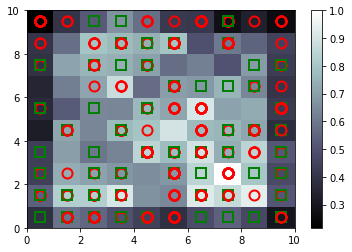

In [ ]:
from pylab import bone, pcolor, colorbar, show, plot
bone()
pcolor(som.distance_map().T)
colorbar()
markers = ['o','s']
colors = ['r','g']
for i,x in enumerate(X):
  w = som.winner(x)
  plot(w[0] + 0.5,
         w[1] + 0.5,
         markers[y[i]],
         markeredgecolor = colors[y[i]],
         markerfacecolor = 'None',
         markersize = 10,
         markeredgewidth = 2)
show()  

# Finding the frauds

In [ ]:
mappings = som.win_map(X)
frauds = np.concatenate((mappings[(7,2)],mappings[(6,1)],mappings[(8,1)]),axis = 0)
frauds = sc.inverse_transform(frauds)

Printing the Fraud Clients

In [ ]:
print('Fraud Client IDs')
for i in frauds[:,0]:
  print(int(i))

Fraud Client IDs
15594305
15664793
15670029
15763579
15662189
15793825
15696361
15568469
15782159
15586479
15717700
15705379
15750104
15646535
15749964
15745375
15654625
15734578
15795527
15802869
15645820
15800554
15750545
15636626


# Unsupervised to supervised Neural Network

Creating a matrix of features

In [ ]:
customers = data_set.iloc[:,1:].values

Creating a Dependant Variable for Supervised DL Model

In [ ]:
is_fraud = np.zeros(len(data_set))
for i in range(len(data_set)):
  if data_set.iloc[i,0] in frauds :
    is_fraud[i] = 1    

Feature scaling for ANN

In [ ]:
from sklearn.preprocessing import StandardScaler
sc= StandardScaler()
customers =  sc.fit_transform(customers)

# Building The ANN

In [ ]:
import tensorflow as tf
ann = tf.keras.models.Sequential()
ann.add(tf.keras.layers.Dense(units=2,activation='relu'))
ann.add(tf.keras.layers.Dense(units =1,activation = 'sigmoid'))

Compiling the ANN

In [ ]:
ann.compile(optimizer = 'adam',loss = 'binary_crossentropy',metrics = ['accuracy'])

Training the ANN

In [ ]:
ann.fit(customers,is_fraud,batch_size = 32,epochs = 5)

Epoch 1/5
22/22 [==============================] - 0s 3ms/step - loss: 0.5562 - accuracy: 0.8217
Epoch 2/5
22/22 [==============================] - 0s 3ms/step - loss: 0.5385 - accuracy: 0.9014
Epoch 3/5
22/22 [==============================] - 0s 3ms/step - loss: 0.5219 - accuracy: 0.9580
Epoch 4/5
22/22 [==============================] - 0s 3ms/step - loss: 0.5060 - accuracy: 0.9652
Epoch 5/5
22/22 [==============================] - 0s 2ms/step - loss: 0.4910 - accuracy: 0.9652


Predicting the Output

In [ ]:
y_pred = ann.predict(customers)
y_pred = np.concatenate((data_set.iloc[:,0:1].values,y_pred),axis =1)
y_pred = y_pred[y_pred[:,1].argsort()]
print(y_pred)

[[1.56058720e+07 4.52518463e-04]
 [1.55933450e+07 2.77751684e-03]
 [1.55809140e+07 1.32870078e-02]
 ...
 [1.56316850e+07 4.67426598e-01]
 [1.56458200e+07 4.67889458e-01]
 [1.57631940e+07 4.68450665e-01]]
